# DBSCAN on MCMC-Sampled Cluster Cores (4 Phone Classes)

**Classes:** `aa`, `n`, `sh`, `sil` — same 4-class setup as `dbscan_4phone_classes_dim12.ipynb`.

## Motivation

On raw MFCC frames DBSCAN collapses classes together because the *tails* of each phone distribution overlap. Nasal tails bleed into vowel tails, fricative tails bleed into silence boundaries. DBSCAN sees a single connected density ridge and returns one giant cluster plus noise.

## Approach

1. Fit a **Gaussian Mixture Model** (one component per class) on the real standardized frames. This gives us a parametric model of the density of each phone: mean $\mu_k$ and covariance $\Sigma_k$.
2. For each component, **MCMC-sample** (Metropolis–Hastings, Gaussian random-walk proposal) from the Gaussian **restricted to its high-density core** — points whose Mahalanobis distance from $\mu_k$ is below a threshold $\tau$. This throws away the tails where classes overlap.
3. Combine the core samples from all 4 components into a synthetic dataset, labelled by source component.
4. Run **DBSCAN on this synthetic core dataset**. If the tail-overlap hypothesis is right, DBSCAN should now recover all 4 clusters cleanly with near-zero noise.

This is a diagnostic experiment: if DBSCAN still fails on the clean cores, the problem is not tail overlap but the 12D MFCC feature itself. If DBSCAN succeeds, the fix is to learn features where classes are *core-only* separable, or to post-process by always keeping a cluster core and discarding boundary frames.

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", "/tmp/mplconfig")

import json
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import chi2
from sklearn.cluster import DBSCAN
from sklearn.manifold import TSNE
from sklearn.metrics import (
    adjusted_mutual_info_score,
    adjusted_rand_score,
    completeness_score,
    homogeneity_score,
    normalized_mutual_info_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

plt.style.use("ggplot")

with open("train_dim12.json", "r") as f:
    data = json.load(f)

RANDOM_SEED = 0
SELECTED_PHONEMES = ["aa", "n", "sh", "sil"]
FRAMES_PER_CLASS = 3_000          # real frames per class used to fit the GMM
SAMPLES_PER_COMPONENT = 2_000     # MCMC synthetic samples per component
MAHAL_THRESHOLD_SIGMA = 1.5       # core cutoff in Mahalanobis "sigmas"
MH_BURN_IN = 500
MH_THIN = 3
MH_PROPOSAL_SCALE = 0.25          # proposal cov = scale^2 * Σ_k; ~30% acceptance in 12D with τ=1.5
TSNE_SIZE = 4_000
TARGET_CLUSTERS = 4

print("classes:", SELECTED_PHONEMES)
print("MCMC samples per component:", SAMPLES_PER_COMPONENT)
print("core Mahalanobis threshold (sigma):", MAHAL_THRESHOLD_SIGMA)

classes: ['aa', 'n', 'sh', 'sil']
MCMC samples per component: 2000
core Mahalanobis threshold (sigma): 1.5


## Build The Real 4-Class Stratified Subset

Identical to the companion notebook. The GMM will be fit on this subset so synthetic samples live in the same standardized MFCC space.

In [2]:
def expand_frame_labels(utt):
    T = len(utt["features"])
    frame_labels = np.full(T, "unlabeled", dtype=object)
    transcript = utt["phn_transcript"]
    for seg_idx, (label, start, end) in enumerate(transcript):
        start = max(0, min(int(start), T))
        end = max(start, min(int(end), T))
        if seg_idx == len(transcript) - 1 and end == T - 1:
            end = T
        if end > start:
            frame_labels[start:end] = label
    return frame_labels


def build_selected_frame_dataset(dataset, selected_phonemes):
    X_parts, y_parts = [], []
    sel = set(selected_phonemes)
    for utt in dataset.values():
        feats = np.asarray(utt["features"], dtype=np.float32)
        frame_labels = expand_frame_labels(utt)
        mask = np.isin(frame_labels, list(sel))
        X_parts.append(feats[mask])
        y_parts.append(frame_labels[mask])
    return np.concatenate(X_parts), np.concatenate(y_parts)

X_full, y_full = build_selected_frame_dataset(data, SELECTED_PHONEMES)

rng = np.random.default_rng(RANDOM_SEED)
idx_parts = []
for phone in SELECTED_PHONEMES:
    idx_phone = np.where(y_full == phone)[0]
    n_take = min(FRAMES_PER_CLASS, len(idx_phone))
    idx_parts.append(rng.choice(idx_phone, size=n_take, replace=False))
sub_idx = np.concatenate(idx_parts)
rng.shuffle(sub_idx)

X_real = X_full[sub_idx]
y_real = y_full[sub_idx]

scaler = StandardScaler()
X_real_scaled = scaler.fit_transform(X_real)

print("real stratified subset:", X_real.shape)
display(pd.Series(y_real).value_counts().rename_axis("phoneme").reset_index(name="count"))

real stratified subset: (12000, 12)


,phoneme,count
0,n,3000
1,sil,3000
2,aa,3000
3,sh,3000


## Fit a 4-Component GMM Seeded By Class Means

A standard GMM fit with `n_components=4` would find its own 4 clusters, not necessarily one per phone. To lock each component to a phone, we initialize the means from the per-phone sample means so the EM refinement stays in the vicinity of the intended class. Covariance type is `full` — MFCC dimensions are correlated.

In [3]:
class_means = np.stack([X_real_scaled[y_real == p].mean(axis=0) for p in SELECTED_PHONEMES])
class_weights = np.array([(y_real == p).mean() for p in SELECTED_PHONEMES])

gmm = GaussianMixture(
    n_components=len(SELECTED_PHONEMES),
    covariance_type="full",
    means_init=class_means,
    weights_init=class_weights / class_weights.sum(),
    random_state=RANDOM_SEED,
    n_init=1,
    max_iter=200,
)
gmm.fit(X_real_scaled)

# Order GMM components to match SELECTED_PHONEMES based on nearest class mean.
order = []
used = set()
for cm in class_means:
    dists = np.linalg.norm(gmm.means_ - cm, axis=1)
    for j in np.argsort(dists):
        if j not in used:
            order.append(int(j)); used.add(int(j)); break

component_phone = {int(j): phone for j, phone in zip(order, SELECTED_PHONEMES)}
mus   = gmm.means_[order]
covs  = gmm.covariances_[order]
wts   = gmm.weights_[order]

print("GMM fitted.")
print("component -> phone mapping:", component_phone)
print("weights:", np.round(wts, 3))

GMM fitted.
component -> phone mapping: {0: 'aa', 1: 'n', 2: 'sh', 3: 'sil'}
weights: [0.256 0.417 0.247 0.081]


## Metropolis–Hastings Sampler For The Core Of Each Component

Target distribution for component $k$:

$$\pi_k(x) \propto \mathcal{N}(x;\mu_k,\Sigma_k)\cdot \mathbf{1}[d_M(x,\mu_k) \le \tau]$$

where $d_M$ is the Mahalanobis distance under $\Sigma_k$ and $\tau$ is `MAHAL_THRESHOLD_SIGMA`. The indicator zeros out the tails, so proposals outside the core are automatically rejected.

Proposal: Gaussian random walk with covariance $s^2\Sigma_k$, where $s$ is `MH_PROPOSAL_SCALE`. Symmetric proposal → Metropolis ratio depends only on the target.

For a 12D standard normal, $\tau=1.5\sigma$ corresponds to a chi-squared probability mass of roughly $P(\chi^2_{12} \le 1.5^2)$ — the interior is *small* in 12D, which is the whole point: we keep only the high-density core.

In [4]:
def mh_sample_core(mu, cov, n_samples, threshold_sigma,
                   burn_in=500, thin=3, proposal_scale=0.5, seed=0):
    rng = np.random.default_rng(seed)
    d = len(mu)
    cov_inv = np.linalg.inv(cov)
    chol_prop = np.linalg.cholesky(cov * (proposal_scale ** 2))
    threshold_sq = threshold_sigma ** 2

    def mahal_sq(x):
        diff = x - mu
        return float(diff @ cov_inv @ diff)

    x = mu.copy()
    samples = np.empty((n_samples, d))
    filled = 0
    step = 0
    accepts = 0
    total = 0
    while filled < n_samples:
        x_prop = x + chol_prop @ rng.standard_normal(d)
        m_prop = mahal_sq(x_prop)
        total += 1
        if m_prop <= threshold_sq:
            m_curr = mahal_sq(x)
            log_ratio = -0.5 * (m_prop - m_curr)
            if np.log(rng.random()) < log_ratio:
                x = x_prop
                accepts += 1
        step += 1
        if step > burn_in and ((step - burn_in) % thin == 0):
            samples[filled] = x
            filled += 1
    return samples, accepts / max(total, 1)


thresh_mass = chi2.cdf(MAHAL_THRESHOLD_SIGMA ** 2, df=12)
print(f"Mahalanobis threshold {MAHAL_THRESHOLD_SIGMA}σ covers ~{thresh_mass:.3%} of a 12D Gaussian.")

X_core_parts, y_core_parts = [], []
accept_rates = {}
for k, phone in enumerate(SELECTED_PHONEMES):
    samples, acc = mh_sample_core(
        mus[k], covs[k], SAMPLES_PER_COMPONENT,
        MAHAL_THRESHOLD_SIGMA,
        burn_in=MH_BURN_IN,
        thin=MH_THIN,
        proposal_scale=MH_PROPOSAL_SCALE,
        seed=RANDOM_SEED + k,
    )
    X_core_parts.append(samples)
    y_core_parts.append(np.full(len(samples), phone, dtype=object))
    accept_rates[phone] = acc

X_core = np.concatenate(X_core_parts, axis=0)
y_core = np.concatenate(y_core_parts, axis=0)

print("MCMC acceptance rates:", {k: round(v, 3) for k, v in accept_rates.items()})
print("synthetic core dataset:", X_core.shape)

Mahalanobis threshold 1.5σ covers ~0.108% of a 12D Gaussian.
MCMC acceptance rates: {'aa': 0.308, 'n': 0.313, 'sh': 0.309, 'sil': 0.313}
synthetic core dataset: (8000, 12)


## Sanity Check: Real Frames vs MCMC Cores

Overlay real and synthetic samples on a shared t-SNE. The synthetic points should sit inside the real cloud for their class, tightly bundled near the component center.

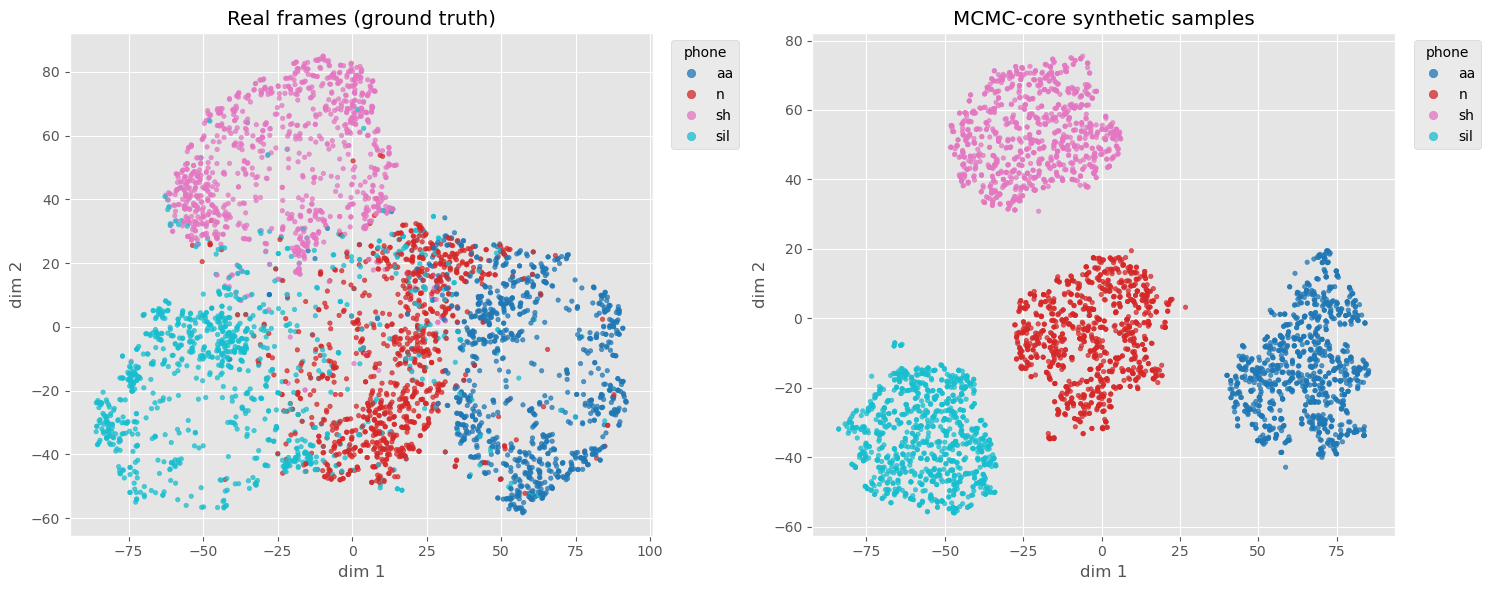

In [5]:
tsne_rng = np.random.default_rng(RANDOM_SEED)

# Cap point counts so a joint t-SNE stays cheap.
n_real_vis = min(TSNE_SIZE, len(X_real_scaled))
n_core_vis = min(TSNE_SIZE, len(X_core))
real_vis_idx = tsne_rng.choice(len(X_real_scaled), size=n_real_vis, replace=False)
core_vis_idx = tsne_rng.choice(len(X_core), size=n_core_vis, replace=False)

X_joint = np.vstack([X_real_scaled[real_vis_idx], X_core[core_vis_idx]])
y_joint = np.concatenate([y_real[real_vis_idx], y_core[core_vis_idx]])
src_joint = np.array(["real"] * n_real_vis + ["core"] * n_core_vis)

joint_embedding = TSNE(
    n_components=2, perplexity=30, init="pca",
    learning_rate="auto", random_state=RANDOM_SEED,
).fit_transform(X_joint)

phone_codes = pd.Categorical(y_joint, categories=SELECTED_PHONEMES).codes
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, src, title in [(axes[0], "real", "Real frames (ground truth)"),
                       (axes[1], "core", "MCMC-core synthetic samples")]:
    mask = src_joint == src
    sc = ax.scatter(joint_embedding[mask, 0], joint_embedding[mask, 1],
                    c=phone_codes[mask], cmap="tab10", s=10, alpha=0.75)
    ax.set_title(title); ax.set_xlabel("dim 1"); ax.set_ylabel("dim 2")
    h, _ = sc.legend_elements()
    ax.legend(h, SELECTED_PHONEMES, title="phone",
              bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

## k-Distance On The Synthetic Core Dataset

Pick `eps` for DBSCAN. Because the cores are tighter, the natural `eps` should be smaller than in the raw-frame notebook.

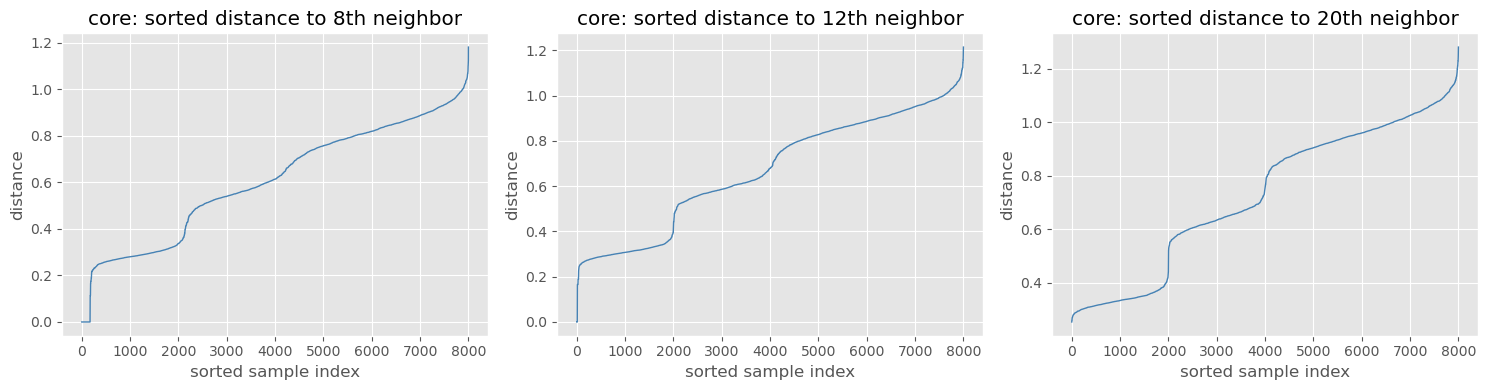

,k,q50,q75,q90,q95,q99
0,8,0.6142,0.8199,0.9039,0.9462,1.0192
1,12,0.6781,0.8861,0.9635,1.0012,1.0713
2,20,0.7578,0.9592,1.0386,1.0784,1.1458


In [6]:
k_values = [8, 12, 20]
rows = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, k in zip(axes, k_values):
    nbrs = NearestNeighbors(n_neighbors=k, algorithm="ball_tree").fit(X_core)
    distances, _ = nbrs.kneighbors(X_core)
    kth_dist = np.sort(distances[:, -1])
    ax.plot(kth_dist, color="steelblue", linewidth=1)
    ax.set_title(f"core: sorted distance to {k}th neighbor")
    ax.set_xlabel("sorted sample index"); ax.set_ylabel("distance")
    q = np.quantile(kth_dist, [0.5, 0.75, 0.9, 0.95, 0.99])
    rows.append({"k": k, "q50": round(float(q[0]), 4), "q75": round(float(q[1]), 4),
                 "q90": round(float(q[2]), 4), "q95": round(float(q[3]), 4), "q99": round(float(q[4]), 4)})
plt.tight_layout(); plt.show()
display(pd.DataFrame(rows))

## DBSCAN Sweep On The MCMC-Core Dataset

Same search protocol as the companion notebook: grid over `(eps, min_samples)`, rank by `|clusters − 4|` then by NMI against the component label. Also keep `ari` because on a clean synthetic set with balanced sizes we expect very high ARI if the hypothesis is right.

In [7]:
def dbscan_sweep(X, y, eps_grid, min_samples_grid, target_clusters=4):
    rows = []
    for min_samples in min_samples_grid:
        for eps in eps_grid:
            labels = DBSCAN(eps=eps, min_samples=min_samples,
                            algorithm="ball_tree", n_jobs=-1).fit_predict(X)
            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            clustered = labels >= 0
            rows.append({
                "min_samples": int(min_samples),
                "eps": float(eps),
                "clusters": int(n_clusters),
                "cluster_gap": int(abs(n_clusters - target_clusters)),
                "noise_fraction": round(float((labels == -1).mean()), 4),
                "coverage": round(float(clustered.mean()), 4),
                "ami": round(float(adjusted_mutual_info_score(y, labels)), 4),
                "nmi": round(float(normalized_mutual_info_score(y, labels)), 4),
                "ari": round(float(adjusted_rand_score(y, labels)), 4),
                "homogeneity": round(float(homogeneity_score(y, labels)), 4),
                "completeness": round(float(completeness_score(y, labels)), 4),
            })
    return pd.DataFrame(rows)

eps_grid = [round(v, 2) for v in np.arange(0.4, 2.1, 0.1)]
min_samples_grid = [5, 8, 10, 15, 20]
sweep_core = dbscan_sweep(X_core, y_core, eps_grid, min_samples_grid,
                          target_clusters=TARGET_CLUSTERS)
ranked_core = sweep_core.sort_values(
    ["cluster_gap", "nmi", "noise_fraction"],
    ascending=[True, False, True]
).reset_index(drop=True)
display(ranked_core.head(15))

,min_samples,eps,clusters,cluster_gap,noise_fraction,coverage,ami,nmi,ari,homogeneity,completeness
0,5,1.0,4,0,0.0004,0.9996,0.9990,0.9990,0.9995,1.0000,0.9980
1,8,1.0,4,0,0.0005,0.9995,0.9987,0.9987,0.9993,1.0000,0.9974
2,10,1.0,4,0,0.0008,0.9992,0.9982,0.9982,0.9990,1.0000,0.9963
3,15,1.0,4,0,0.0034,0.9966,0.9936,0.9936,0.9955,1.0000,0.9873
4,20,1.0,4,0,0.0100,0.9900,0.9846,0.9846,0.9871,0.9995,0.9701
5,8,0.9,4,0,0.0154,0.9846,0.9763,0.9763,0.9803,0.9967,0.9567
6,10,0.4,4,0,0.7460,0.2540,0.5727,0.5731,0.3333,0.4088,0.9579
7,5,1.1,3,1,0.0000,1.0000,0.8571,0.8571,0.7142,0.7500,1.0000
8,5,1.2,3,1,0.0000,1.0000,0.8571,0.8571,0.7142,0.7500,1.0000
9,5,1.3,3,1,0.0000,1.0000,0.8571,0.8571,0.7142,0.7500,1.0000


In [8]:
best_row = ranked_core.iloc[0]
selected_eps = float(best_row["eps"])
selected_min_samples = int(best_row["min_samples"])

labels_core = DBSCAN(eps=selected_eps, min_samples=selected_min_samples,
                     algorithm="ball_tree", n_jobs=-1).fit_predict(X_core)
n_clusters = len(set(labels_core)) - (1 if -1 in labels_core else 0)

print(f"selected eps         : {selected_eps}")
print(f"selected min_samples : {selected_min_samples}")
print(f"clusters found       : {n_clusters}")
print(f"noise fraction       : {(labels_core == -1).mean():.4f}")
print(f"coverage             : {(labels_core >= 0).mean():.4f}")
print(f"AMI  : {adjusted_mutual_info_score(y_core, labels_core):.4f}")
print(f"NMI  : {normalized_mutual_info_score(y_core, labels_core):.4f}")
print(f"ARI  : {adjusted_rand_score(y_core, labels_core):.4f}")

ct = pd.crosstab(pd.Series(y_core, name="true"),
                 pd.Series(labels_core, name="cluster"))
display(ct)

selected eps         : 1.0
selected min_samples : 5
clusters found       : 4
noise fraction       : 0.0004
coverage             : 0.9996
AMI  : 0.9990
NMI  : 0.9990
ARI  : 0.9995


cluster,-1,0,1,2,3
true,,,,,
aa,3,1997,0,0,0
n,0,0,2000,0,0
sh,0,0,0,2000,0
sil,0,0,0,0,2000


## t-SNE of Core Dataset: Truth vs DBSCAN

Same 2D embedding, colored two ways.

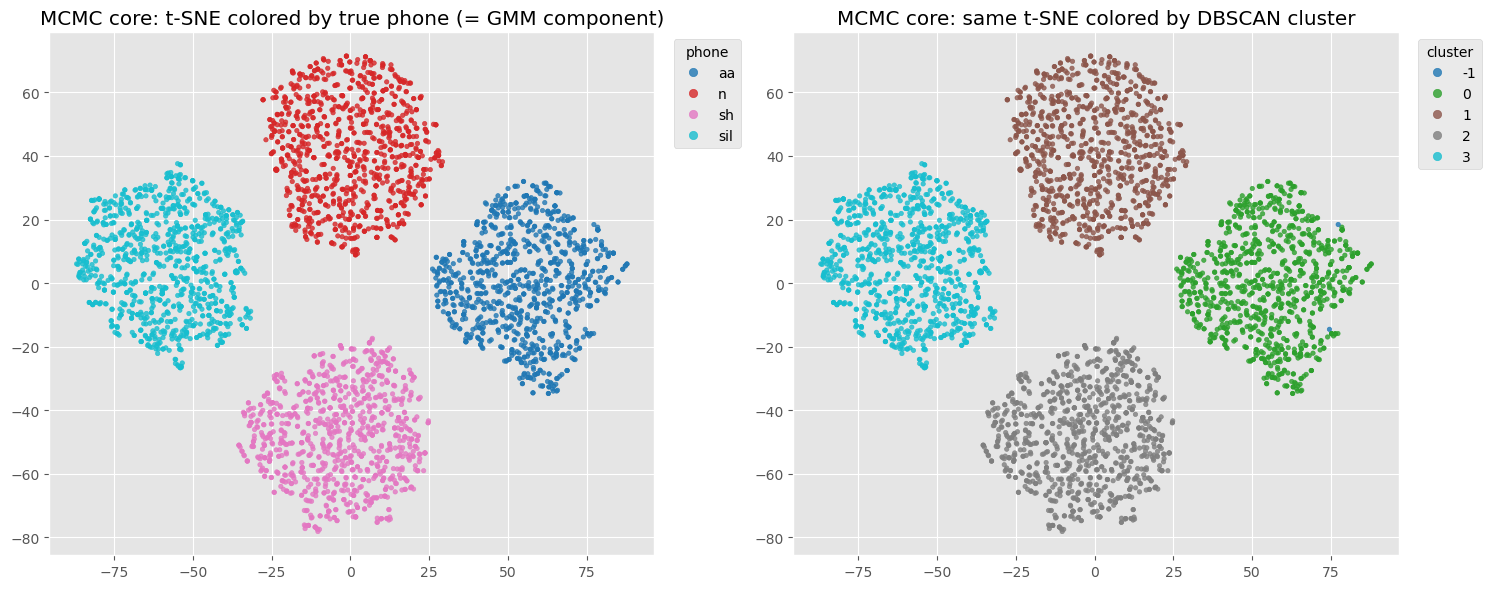

In [9]:
core_vis_n = min(TSNE_SIZE, len(X_core))
vis_idx = np.random.default_rng(RANDOM_SEED).choice(len(X_core), size=core_vis_n, replace=False)
emb_core = TSNE(n_components=2, perplexity=30, init="pca",
                learning_rate="auto", random_state=RANDOM_SEED).fit_transform(X_core[vis_idx])

true_codes = pd.Categorical(y_core[vis_idx], categories=SELECTED_PHONEMES).codes
cluster_vis = labels_core[vis_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sc0 = axes[0].scatter(emb_core[:, 0], emb_core[:, 1],
                      c=true_codes, cmap="tab10", s=10, alpha=0.8)
axes[0].set_title("MCMC core: t-SNE colored by true phone (= GMM component)")
h0, _ = sc0.legend_elements()
axes[0].legend(h0, SELECTED_PHONEMES, title="phone",
               bbox_to_anchor=(1.02, 1), loc="upper left")

sc1 = axes[1].scatter(emb_core[:, 0], emb_core[:, 1],
                      c=cluster_vis, cmap="tab10", s=10, alpha=0.8)
axes[1].set_title("MCMC core: same t-SNE colored by DBSCAN cluster")
if np.any(cluster_vis >= 0):
    uniq = sorted(set(cluster_vis.tolist()))
    h1, _ = sc1.legend_elements()
    axes[1].legend(h1[:len(uniq)], [str(c) for c in uniq], title="cluster",
                   bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(); plt.show()

## Transfer: Does The Core-Tuned DBSCAN Work On Real Frames?

The training question behind all of this: once DBSCAN succeeds on the synthetic cores, can the same `(eps, min_samples)` be applied to the **real** standardized frames and recover useful phone structure? If not, the failure on real data is confirmed to be tail overlap, and the fix must happen upstream (better features, core-only filtering, denoising).

In [10]:
labels_transfer = DBSCAN(eps=selected_eps, min_samples=selected_min_samples,
                         algorithm="ball_tree", n_jobs=-1).fit_predict(X_real_scaled)
n_clusters_r = len(set(labels_transfer)) - (1 if -1 in labels_transfer else 0)

print("core-tuned (eps, min_samples) applied to real frames:")
print(f"  eps={selected_eps}, min_samples={selected_min_samples}")
print(f"  clusters found : {n_clusters_r}")
print(f"  noise fraction : {(labels_transfer == -1).mean():.4f}")
print(f"  NMI  : {normalized_mutual_info_score(y_real, labels_transfer):.4f}")
print(f"  ARI  : {adjusted_rand_score(y_real, labels_transfer):.4f}")

display(pd.crosstab(pd.Series(y_real, name="true"),
                    pd.Series(labels_transfer, name="cluster")))

core-tuned (eps, min_samples) applied to real frames:
  eps=1.0, min_samples=5
  clusters found : 11
  noise fraction : 0.8484
  NMI  : 0.2302
  ARI  : 0.0456


cluster,-1,0,1,2,3,4,5,6,7,8,9,10
true,,,,,,,,,,,,
aa,3000,0,0,0,0,0,0,0,0,0,0,0
n,3000,0,0,0,0,0,0,0,0,0,0,0
sh,2157,0,806,7,8,4,5,3,5,5,0,0
sil,2024,966,1,0,0,0,0,0,0,0,5,4


## Summary

Expected reading:

- **Core DBSCAN NMI high (> 0.9) with 4 clusters and near-zero noise** → DBSCAN works perfectly once overlapping tails are removed. The raw-frame failure is a tail-overlap problem, not a DBSCAN problem.
- **Core DBSCAN still merges components** → the GMM components themselves overlap too much at their cores. Tighten `MAHAL_THRESHOLD_SIGMA` (e.g. 1.0) and re-run.
- **Transfer to real frames still collapses** → the mapping from "clean cores" to "real frames" loses the separation because boundary frames pull density between classes; the practical fix is to keep a core-filter at inference time (discard frames with low max component posterior), not to use raw DBSCAN.